# HaluEval — Protocols A & B

**Protocol A** — paired discrimination: model sees context + one candidate, answers Yes/No hallucinated.
**Protocol B** — free generation + word-overlap scoring, then LR / NN detectors.

Models: `llama3.2:1b`, `qwen3:1.7b`, `gemma3:1b`.

Outputs under `results/` (per-model, never overwrite another model):
- Protocol A: `protocol_a_progress_<model>.json`, `protocol_a_run_<model>.csv`, `protocol_a_metrics_<model>.csv`
- Protocol B: `ollama_progress_<model>.json`, `ollama_run_<model>.csv`, `task_metrics_<model>.csv`
- Joint: `combined_results.json`, `protocol_comparison.csv`, figures + `figure_captions.md`

Requires: `ollama serve` and `ollama pull` for each model tag.


In [1]:
import json
import random
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Dense
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import BinaryAccuracy
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tqdm.notebook import tqdm

%matplotlib inline

In [2]:
DATA_DIR = Path("../data")
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)

OLLAMA_URL = "http://localhost:11434"
MODELS = ["llama3.2:1b", "qwen3:1.7b", "gemma3:1b"]
N_PER_TASK = 500
MAX_CTX_CHARS = 2000
SLEEP_SEC = 1.5
GEN_SEC_ESTIMATE = 2.0
RANDOM_SEED = 42
TASKS = ["qa", "dialogue", "summarization", "general"]


def model_slug(model):
    return model.replace(":", "_").replace("/", "_")


def progress_path(model):
    return RESULTS_DIR / f"ollama_progress_{model_slug(model)}.json"


def run_csv_path(model):
    return RESULTS_DIR / f"ollama_run_{model_slug(model)}.csv"


def metrics_csv_path(model):
    return RESULTS_DIR / f"task_metrics_{model_slug(model)}.csv"

## Migrate legacy single-model files (Llama only)

If `ollama_progress.json` exists from the earlier Llama-only run, copy it into the new per-model path without overwriting a newer file.

In [3]:
legacy = RESULTS_DIR / "ollama_progress.json"
llama_prog = progress_path("llama3.2:1b")
if legacy.exists() and not llama_prog.exists():
    llama_prog.write_text(legacy.read_text(encoding="utf-8"))
    print(f"migrated {legacy.name} -> {llama_prog.name}")
else:
    print("no migration needed")

legacy_run = RESULTS_DIR / "ollama_run.csv"
llama_run = run_csv_path("llama3.2:1b")
if legacy_run.exists() and not llama_run.exists():
    llama_run.write_text(legacy_run.read_text(encoding="utf-8"))
    print(f"migrated {legacy_run.name} -> {llama_run.name}")

no migration needed


## Check Ollama + required model tags

In [4]:
try:
    tags = requests.get(f"{OLLAMA_URL}/api/tags", timeout=5).json()
except requests.ConnectionError:
    raise ConnectionError("Start Ollama first: ollama serve")

available = {m["name"] for m in tags.get("models", [])}
print("installed:", sorted(available))

missing = [m for m in MODELS if m not in available]
if missing:
    print("MISSING — pull before running:")
    for m in missing:
        print(f"  ollama pull {m}")
else:
    print("all MODELS present")

warmup_model = next((m for m in MODELS if m in available), None)
if warmup_model:
    requests.post(
        f"{OLLAMA_URL}/api/chat",
        json={
            "model": warmup_model,
            "messages": [{"role": "user", "content": "hi"}],
            "stream": False,
            "options": {"num_predict": 5},
        },
        timeout=60,
    )
    print("warmup ok:", warmup_model)

installed: ['gemma3:1b', 'llama3.1:8b', 'llama3.2:1b', 'qwen3:1.7b']
all MODELS present
warmup ok: llama3.2:1b


## Load HaluEval data (shared sample set across models)

In [5]:
def load_jsonl(path):
    rows = []
    for line in path.read_text(encoding="utf-8").splitlines():
        if line.strip():
            rows.append(json.loads(line))
    return rows


def to_sample(task, row, idx):
    if task == "qa":
        return dict(
            task=task,
            sample_id=idx,
            question=row["question"],
            context=row.get("knowledge", ""),
            ground_truth=row["right_answer"],
            hallucinated=row["hallucinated_answer"],
        )
    if task == "dialogue":
        return dict(
            task=task,
            sample_id=idx,
            question=row.get("dialogue_history", ""),
            context=row.get("knowledge", ""),
            ground_truth=row["right_response"],
            hallucinated=row["hallucinated_response"],
        )
    if task == "summarization":
        return dict(
            task=task,
            sample_id=idx,
            question="Summarize this document.",
            context=row.get("document", ""),
            ground_truth=row["right_summary"],
            hallucinated=row["hallucinated_summary"],
        )
    label = str(row.get("hallucination_label", row.get("hallucination", ""))).lower()
    resp = row.get("chatgpt_response", "")
    return dict(
        task=task,
        sample_id=idx,
        question=row["user_query"],
        context="",
        ground_truth=resp if label in ("no", "n") else "",
        hallucinated=resp if label in ("yes", "y") else "",
    )

In [6]:
random.seed(RANDOM_SEED)
samples = []
counts = {}
shortfalls = []

for task in TASKS:
    path = DATA_DIR / f"{task}_data.json"
    rows = load_jsonl(path)
    n = min(N_PER_TASK, len(rows))
    counts[task] = {"n_used": n, "n_available": len(rows), "n_requested": N_PER_TASK}
    if n < N_PER_TASK:
        shortfalls.append((task, n, N_PER_TASK, len(rows)))
    rng = random.Random(RANDOM_SEED + TASKS.index(task))
    picked = rng.sample(rows, n)
    for i, row in enumerate(picked):
        samples.append(to_sample(task, row, i))

counts

{'qa': {'n_used': 50, 'n_available': 50, 'n_requested': 500},
 'dialogue': {'n_used': 20, 'n_available': 20, 'n_requested': 500},
 'summarization': {'n_used': 20, 'n_available': 20, 'n_requested': 500},
 'general': {'n_used': 20, 'n_available': 20, 'n_requested': 500}}

In [7]:
if shortfalls:
    print("DATA SHORTFALL — not silently truncating past available rows:")
    for task, used, requested, available in shortfalls:
        print(f"  {task}: using {used}/{requested} (file has {available} lines)")
    print("Populate DATA_DIR with >=500 lines per file before claiming N_PER_TASK=500.")
else:
    print(f"all tasks have >= {N_PER_TASK} rows")

print("total samples (shared across models):", len(samples))

DATA SHORTFALL — not silently truncating past available rows:
  qa: using 50/500 (file has 50 lines)
  dialogue: using 20/500 (file has 20 lines)
  summarization: using 20/500 (file has 20 lines)
  general: using 20/500 (file has 20 lines)
Populate DATA_DIR with >=500 lines per file before claiming N_PER_TASK=500.
total samples (shared across models): 110


## Wall-time estimate (run before generation)

Counts remaining `(model, sample)` pairs from per-model progress files. Does **not** start generation.

In [8]:
def sample_key(s):
    return f"{s['task']}_{s['sample_id']}"


def load_progress(model):
    path = progress_path(model)
    if not path.exists():
        return []
    return json.loads(path.read_text(encoding="utf-8"))


sec_per_call = SLEEP_SEC + GEN_SEC_ESTIMATE
estimate_rows = []
total_remaining = 0

for model in MODELS:
    done = {sample_key(r) for r in load_progress(model)}
    by_task = {}
    for s in samples:
        t = s["task"]
        by_task.setdefault(t, {"done": 0, "todo": 0})
        if sample_key(s) in done:
            by_task[t]["done"] += 1
        else:
            by_task[t]["todo"] += 1
    for task, d in by_task.items():
        rem = d["todo"]
        total_remaining += rem
        estimate_rows.append({
            "model": model,
            "task": task,
            "done": d["done"],
            "remaining": rem,
            "est_minutes": round(rem * sec_per_call / 60, 1),
        })

estimate_df = pd.DataFrame(estimate_rows)
total_hours = total_remaining * sec_per_call / 3600
print(f"SLEEP_SEC={SLEEP_SEC}, GEN_SEC_ESTIMATE={GEN_SEC_ESTIMATE}, sec/call≈{sec_per_call}")
print(f"remaining calls: {total_remaining}")
print(f"estimated wall time: {total_hours:.1f} hours ({total_hours*60:.0f} minutes)")
estimate_df

SLEEP_SEC=1.5, GEN_SEC_ESTIMATE=2.0, sec/call≈3.5
remaining calls: 0
estimated wall time: 0.0 hours (0 minutes)


,model,task,done,remaining,est_minutes
0,llama3.2:1b,qa,50,0,0.0
1,llama3.2:1b,dialogue,20,0,0.0
2,llama3.2:1b,summarization,20,0,0.0
3,llama3.2:1b,general,20,0,0.0
4,qwen3:1.7b,qa,50,0,0.0
5,qwen3:1.7b,dialogue,20,0,0.0
6,qwen3:1.7b,summarization,20,0,0.0
7,qwen3:1.7b,general,20,0,0.0
8,gemma3:1b,qa,50,0,0.0
9,gemma3:1b,dialogue,20,0,0.0


In [9]:
DEADLINE_HOURS = 4.0

if total_hours > DEADLINE_HOURS:
    print(f"DOES NOT FIT a {DEADLINE_HOURS:.0f}h window at current settings.")
    print("Do NOT silently truncate N_PER_TASK.")
    print()
    print("Suggested drop order (largest remaining first, keep Llama if already partly done):")
    ranked = (
        estimate_df.groupby("model")["remaining"]
        .sum()
        .sort_values(ascending=False)
    )
    print(ranked)
    print()
    print("Practical options:")
    print("  1. Drop gemma3:1b entirely (largest new cost if not started)")
    print("  2. Drop task=general for all unfinished models (often least informative)")
    print("  3. Drop summarization for unfinished models (longest contexts / slowest)")
    print("  4. Keep N_PER_TASK=500 but only finish llama3.2:1b + one other model")
else:
    print(f"Fits within {DEADLINE_HOURS:.0f}h estimate (remaining {total_hours:.1f}h).")

Fits within 4h estimate (remaining 0.0h).


## Ollama helpers

**Stop here if the estimate exceeds your deadline.** Set `RUN_GENERATION = True` only when ready.

In [10]:
RUN_GENERATION = False


def trim(text, n=MAX_CTX_CHARS):
    text = str(text or "")
    return text if len(text) <= n else text[:n] + "..."


def build_prompt(sample):
    task, ctx, q = sample["task"], trim(sample["context"]), sample["question"]
    if task == "summarization":
        return f"Summarize in 2-3 sentences.\n\nDocument:\n{ctx}"
    if task == "dialogue":
        return f"Knowledge:\n{ctx}\n\nDialogue:\n{trim(q, 800)}\n\nNext response (short):"
    if task == "general":
        return f"{q}\n\nShort answer:"
    return f"Context:\n{ctx}\n\nQuestion: {q}\n\nShort answer:"


def ask_ollama(model, prompt, retries=4):
    payload = {
        "model": model,
        "messages": [{"role": "user", "content": prompt}],
        "stream": False,
        "think": False,
        "options": {"num_predict": 80, "temperature": 0.1},
    }
    for attempt in range(retries):
        try:
            r = requests.post(f"{OLLAMA_URL}/api/chat", json=payload, timeout=180)
            r.raise_for_status()
            msg = r.json().get("message", {})
            content = (msg.get("content") or "").strip()
            if content:
                return content
            thinking = (msg.get("thinking") or "").strip()
            return thinking
        except (requests.ConnectionError, requests.Timeout):
            if attempt == retries - 1:
                raise
            time.sleep(3 * (attempt + 1))
    return ""

In [11]:
if not RUN_GENERATION:
    print("RUN_GENERATION is False — no Ollama calls. Set True and re-run this cell to generate.")
else:
    tags = requests.get(f"{OLLAMA_URL}/api/tags", timeout=5).json()
    available = {m["name"] for m in tags.get("models", [])}
    for model in MODELS:
        if model not in available:
            print(f"SKIP {model}: not installed (ollama pull {model})")
            continue
        results = load_progress(model)
        done = {sample_key(r) for r in results}
        print(f"{model}: {len(done)} done, {len(samples) - len(done)} remaining")
        for s in tqdm(samples, desc=model):
            key = sample_key(s)
            if key in done:
                continue
            prompt = build_prompt(s)
            answer = ask_ollama(model, prompt)
            row = {**s, "model": model, "prompt_sent": prompt, "llama_answer": answer}
            results.append(row)
            done.add(key)
            progress_path(model).write_text(json.dumps(results, indent=2), encoding="utf-8")
            time.sleep(SLEEP_SEC)
        df_model = pd.DataFrame(results)
        df_model.to_csv(run_csv_path(model), index=False)
        print(f"saved {run_csv_path(model)} ({len(df_model)} rows)")

RUN_GENERATION is False — no Ollama calls. Set True and re-run this cell to generate.


## Protocol A — Yes/No hallucination discrimination

For each sample the model judges the **truth** candidate (gold=0) and the **hallucinated**
candidate (gold=1) separately. Positive class = hallucinated. Metrics: accuracy, precision,
recall, F1, confusion matrix. Set `RUN_PROTOCOL_A = True` to call Ollama (resumable).


In [12]:
RUN_PROTOCOL_A = False


def protocol_a_progress_path(model):
    return RESULTS_DIR / f"protocol_a_progress_{model_slug(model)}.json"


def protocol_a_run_path(model):
    return RESULTS_DIR / f"protocol_a_run_{model_slug(model)}.csv"


def protocol_a_metrics_path(model):
    return RESULTS_DIR / f"protocol_a_metrics_{model_slug(model)}.csv"


def build_protocol_a_prompt(sample, candidate):
    return (
        "Decide whether the candidate answer is a hallucination "
        "(fabricated or unsupported by the context). "
        "Reply with only Yes or No.\n\n"
        f"Context:\n{trim(sample['context'])}\n\n"
        f"Question / dialogue / task:\n{trim(sample['question'], 800)}\n\n"
        f"Candidate answer:\n{trim(candidate, 800)}\n\n"
        "Is the candidate hallucinated? Yes or No:"
    )


def parse_yes_no(text):
    t = re.sub(r"[^a-z\s]", " ", str(text or "").strip().lower())
    tokens = t.split()
    if not tokens:
        return None
    if tokens[0] in ("yes", "y"):
        return 1
    if tokens[0] in ("no", "n"):
        return 0
    if "yes" in tokens and "no" not in tokens:
        return 1
    if "no" in tokens and "yes" not in tokens:
        return 0
    return None


def judgment_items(samples):
    items = []
    for s in samples:
        if str(s.get("ground_truth") or "").strip():
            items.append({**s, "candidate_type": "truth", "candidate": s["ground_truth"], "gold_hallucinated": 0})
        if str(s.get("hallucinated") or "").strip():
            items.append({**s, "candidate_type": "hallucinated", "candidate": s["hallucinated"], "gold_hallucinated": 1})
    return items


def judgment_key(row):
    return f"{row['task']}|{row['sample_id']}|{row['candidate_type']}"


def detection_metrics_full(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn), "n": int(len(y_true)),
    }


In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score

items_a = judgment_items(samples)
print(f"Protocol A judgement slots: {len(items_a)}")

if not RUN_PROTOCOL_A:
    print("RUN_PROTOCOL_A is False — no Ollama calls. Set True to generate/resume.")
else:
    tags = requests.get(f"{OLLAMA_URL}/api/tags", timeout=5).json()
    available = {m["name"] for m in tags.get("models", [])}
    for model in MODELS:
        if model not in available:
            print(f"MISSING Protocol A for {model}: not installed")
            continue
        path = protocol_a_progress_path(model)
        results = json.loads(path.read_text()) if path.exists() else []
        done = {judgment_key(r) for r in results}
        remaining = [it for it in items_a if judgment_key(it) not in done]
        print(f"{model}: {len(done)} done, {len(remaining)} remaining")
        for it in tqdm(remaining, desc=f"Protocol A {model}"):
            prompt = build_protocol_a_prompt(it, it["candidate"])
            raw = ask_ollama(model, prompt)
            # override num_predict via a short follow-up style: ask_ollama uses 80; accept that
            pred = parse_yes_no(raw)
            if pred is None:
                pred = 1 if "yes" in raw.lower() else 0
            row = {
                "task": it["task"], "sample_id": it["sample_id"], "model": model,
                "candidate_type": it["candidate_type"], "candidate": it["candidate"],
                "gold_hallucinated": it["gold_hallucinated"], "prompt_sent": prompt,
                "judgment_raw": raw, "pred_hallucinated": int(pred),
            }
            row["correct"] = int(row["pred_hallucinated"] == row["gold_hallucinated"])
            results.append(row)
            path.write_text(json.dumps(results, indent=2), encoding="utf-8")
            time.sleep(SLEEP_SEC)
        df = pd.DataFrame(results)
        df.to_csv(protocol_a_run_path(model), index=False)
        rows = []
        for task in sorted(df["task"].unique().tolist()) + ["overall"]:
            sub = df if task == "overall" else df[df["task"] == task]
            rows.append({"model": model, "task": task, **detection_metrics_full(
                sub["gold_hallucinated"].values, sub["pred_hallucinated"].values)})
        metrics = pd.DataFrame(rows)
        metrics.to_csv(protocol_a_metrics_path(model), index=False)
        print(model)
        display(metrics.round(3))


Protocol A judgement slots: 200
RUN_PROTOCOL_A is False — no Ollama calls. Set True to generate/resume.


In [14]:
protocol_a_dfs = {}
for model in MODELS:
    path = protocol_a_run_path(model)
    if not path.exists():
        print(f"MISSING Protocol A run for {model}")
        continue
    df = pd.read_csv(path)
    protocol_a_dfs[model] = df
    rows = []
    for task in sorted(df["task"].unique().tolist()) + ["overall"]:
        sub = df if task == "overall" else df[df["task"] == task]
        rows.append({"model": model, "task": task, **detection_metrics_full(
            sub["gold_hallucinated"].values, sub["pred_hallucinated"].values)})
    metrics = pd.DataFrame(rows)
    metrics.to_csv(protocol_a_metrics_path(model), index=False)
    print(model)
    display(metrics.round(3))


llama3.2:1b


,model,task,accuracy,precision,recall,f1,tp,fp,tn,fn,n
0,llama3.2:1b,dialogue,0.50,0.500,0.950,0.655,19,19,1,1,40
1,llama3.2:1b,general,0.65,0.650,1.000,0.788,13,7,0,0,20
2,llama3.2:1b,qa,0.53,0.517,0.900,0.657,45,42,8,5,100
3,llama3.2:1b,summarization,0.50,0.500,1.000,0.667,20,20,0,0,40
4,llama3.2:1b,overall,0.53,0.524,0.942,0.674,97,88,9,6,200


qwen3:1.7b


,model,task,accuracy,precision,recall,f1,tp,fp,tn,fn,n
0,qwen3:1.7b,dialogue,0.325,0.294,0.250,0.270,5,12,8,15,40
1,qwen3:1.7b,general,0.350,0.500,0.462,0.480,6,6,1,7,20
2,qwen3:1.7b,qa,0.200,0.250,0.300,0.273,15,45,5,35,100
3,qwen3:1.7b,summarization,0.400,0.438,0.700,0.538,14,18,2,6,40
4,qwen3:1.7b,overall,0.280,0.331,0.388,0.357,40,81,16,63,200


gemma3:1b


,model,task,accuracy,precision,recall,f1,tp,fp,tn,fn,n
0,gemma3:1b,dialogue,0.500,0.500,0.750,0.600,15,15,5,5,40
1,gemma3:1b,general,0.350,0.500,0.462,0.480,6,6,1,7,20
2,gemma3:1b,qa,0.320,0.375,0.540,0.443,27,45,5,23,100
3,gemma3:1b,summarization,0.500,0.500,0.950,0.655,19,19,1,1,40
4,gemma3:1b,overall,0.395,0.441,0.650,0.525,67,85,12,36,200


## Accuracy scoring (unchanged logic)

`norm`, `word_overlap`, and `is_correct` match the Llama-only notebook. Do not change without flagging.

In [15]:
def norm(s):
    return re.sub(r"[^\w\s]", "", str(s).lower()).strip()


def word_overlap(a, b):
    wa, wb = set(norm(a).split()), set(norm(b).split())
    if not wa or not wb:
        return 0.0
    return len(wa & wb) / len(wa | wb)


def is_correct(row):
    truth, hall, ans, task = row["ground_truth"], row["hallucinated"], row["llama_answer"], row["task"]
    t, a = norm(truth), norm(ans)
    if not t:
        return False
    if task == "qa":
        if t in a:
            return True
        tw = set(t.split())
        if tw and tw <= set(a.split()):
            return True
    ot = word_overlap(ans, truth)
    oh = word_overlap(ans, hall) if hall else 0.0
    return ot > oh


def score_dataframe(df):
    df = df.copy()
    df["overlap_truth"] = df.apply(lambda r: word_overlap(r["llama_answer"], r["ground_truth"]), axis=1)
    df["overlap_hall"] = df.apply(lambda r: word_overlap(r["llama_answer"], r["hallucinated"]), axis=1)
    df["correct"] = df.apply(is_correct, axis=1)
    return df

In [16]:
scored = {}
all_metrics = []

for model in MODELS:
    path = run_csv_path(model)
    if not path.exists():
        print(f"MISSING Protocol B run for {model}: {path.name}")
        continue
    df = pd.read_csv(path)
    if "model" not in df.columns:
        df["model"] = model
    df = score_dataframe(df)
    scored[model] = df

    task_metrics = df.groupby("task").agg(
        accuracy=("correct", "mean"),
        avg_overlap_truth=("overlap_truth", "mean"),
        avg_overlap_hall=("overlap_hall", "mean"),
        n=("correct", "count"),
    ).round(3)
    overall_acc = df["correct"].mean()
    task_metrics.loc["overall"] = [
        overall_acc,
        df["overlap_truth"].mean(),
        df["overlap_hall"].mean(),
        len(df),
    ]
    task_metrics = task_metrics.reset_index()
    task_metrics.insert(0, "model", model)
    task_metrics.to_csv(metrics_csv_path(model), index=False)
    all_metrics.append(task_metrics)
    print(model)
    display(task_metrics)

if all_metrics:
    metrics_all = pd.concat(all_metrics, ignore_index=True)
    metrics_all.to_csv(RESULTS_DIR / "task_metrics_all_models.csv", index=False)
else:
    print("No Protocol B CSVs found yet.")

llama3.2:1b


,model,task,accuracy,avg_overlap_truth,avg_overlap_hall,n
0,llama3.2:1b,dialogue,0.350000,0.057000,0.079000,20.0
1,llama3.2:1b,general,0.300000,0.037000,0.116000,20.0
2,llama3.2:1b,qa,0.680000,0.110000,0.322000,50.0
3,llama3.2:1b,summarization,0.200000,0.185000,0.232000,20.0
4,llama3.2:1b,overall,0.463636,0.100594,0.223774,110.0


qwen3:1.7b


,model,task,accuracy,avg_overlap_truth,avg_overlap_hall,n
0,qwen3:1.7b,dialogue,0.150000,0.05800,0.10700,20.0
1,qwen3:1.7b,general,0.300000,0.02800,0.09100,20.0
2,qwen3:1.7b,qa,0.700000,0.42700,0.21400,50.0
3,qwen3:1.7b,summarization,0.100000,0.16200,0.21000,20.0
4,qwen3:1.7b,overall,0.418182,0.23945,0.17153,110.0


gemma3:1b


,model,task,accuracy,avg_overlap_truth,avg_overlap_hall,n
0,gemma3:1b,dialogue,0.250000,0.072000,0.109000,20.0
1,gemma3:1b,general,0.300000,0.027000,0.068000,20.0
2,gemma3:1b,qa,0.740000,0.571000,0.091000,50.0
3,gemma3:1b,summarization,0.100000,0.143000,0.209000,20.0
4,gemma3:1b,overall,0.454545,0.303361,0.111236,110.0


## Classifiers per model (logistic regression + Keras NN)

In [17]:
classifier_rows = []
clf_artifacts = {}

for model, df in scored.items():
    df = df.reset_index(drop=True)
    X = df[["overlap_truth", "overlap_hall"]].values
    # Positive class = HALLUCINATED (mirrors Protocol A positive=hallucinated).
    # is_correct is unchanged; we only invert it for the reported detection label.
    y_hall = (~df["correct"].astype(bool)).astype(int).values
    idx = np.arange(len(df))
    if len(np.unique(y_hall)) < 2:
        print(f"SKIP classifiers for {model}: only one class in labels")
        continue

    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X, y_hall, idx, test_size=0.25, random_state=RANDOM_SEED, stratify=y_hall
    )
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    grid = GridSearchCV(LogisticRegression(max_iter=1000), {"C": [0.1, 1, 10]}, cv=3)
    grid.fit(X_train_s, y_train)
    lr_proba = grid.predict_proba(X_test_s)[:, 1]
    lr_pred = (lr_proba >= 0.5).astype(int)
    lr_acc = accuracy_score(y_test, lr_pred)

    nn = Sequential([
        Dense(8, activation="relu", input_shape=(2,)),
        Dense(1, activation="sigmoid"),
    ])
    nn.compile(optimizer=Adam(0.01), loss=BinaryCrossentropy(), metrics=[BinaryAccuracy()])
    nn.fit(X_train_s, y_train, epochs=40, batch_size=16, verbose=0)
    nn_proba = nn.predict(X_test_s, verbose=0).ravel()
    nn_pred = (nn_proba >= 0.5).astype(int)
    nn_acc = accuracy_score(y_test, nn_pred)

    clf_artifacts[model] = {
        "idx_test": idx_test,
        "task_test": df.loc[idx_test, "task"].values,
        "sample_id_test": df.loc[idx_test, "sample_id"].values,
        "y_test_hall": y_test,
        "lr_proba_hall": lr_proba,
        "lr_pred_hall": lr_pred,
        "nn_proba_hall": nn_proba,
        "nn_pred_hall": nn_pred,
    }

    classifier_rows.append({
        "model": model,
        "direct_accuracy": float(df["correct"].mean()),
        "logistic_regression_accuracy": float(lr_acc),
        "neural_network_accuracy": float(nn_acc),
        "n": len(df),
    })
    print(model, "lr", round(lr_acc, 3), "nn", round(nn_acc, 3))

if classifier_rows:
    clf_df = pd.DataFrame(classifier_rows)
    clf_df.to_csv(RESULTS_DIR / "model_accuracy_all_models.csv", index=False)
    display(clf_df)
else:
    print("No classifiers trained — missing scored runs.")

/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


llama3.2:1b lr 0.643 nn 0.679


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


qwen3:1.7b lr 0.75 nn 0.821


/opt/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


gemma3:1b lr 0.857 nn 0.857


,model,direct_accuracy,logistic_regression_accuracy,neural_network_accuracy,n
0,llama3.2:1b,0.463636,0.642857,0.678571,110
1,qwen3:1.7b,0.418182,0.750000,0.821429,110
2,gemma3:1b,0.454545,0.857143,0.857143,110


## Step 2 — Protocol B detection metrics + classifier probabilities

Treat Protocol B as a hallucination **detector**: the classifier predicts whether
the free-generation answer is hallucinated. **Positive class = hallucinated**, matching
Protocol A. `is_correct` / `word_overlap` are unchanged — the label is inverted
(`hallucinated = not correct`) for reporting only.

Reports precision / recall / F1 and confusion matrix (TP/FP/TN/FN) per `(model, task)`
on the held-out test split, and saves per-item probabilities (`predict_proba` for LR,
raw sigmoid for the NN) for later AUC.


In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix


def detection_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        "n": int(len(y_true)),
    }


if not clf_artifacts:
    print("No classifier artifacts — Protocol B detection metrics skipped.")
else:
    for model in MODELS:
        if model not in clf_artifacts:
            print(f"MISSING Protocol B detection metrics for {model}")
            continue
        a = clf_artifacts[model]
        proba_df = pd.DataFrame({
            "task": a["task_test"],
            "sample_id": a["sample_id_test"],
            "y_true_hallucinated": a["y_test_hall"],
            "lr_proba_hall": a["lr_proba_hall"],
            "lr_pred_hall": a["lr_pred_hall"],
            "nn_proba_hall": a["nn_proba_hall"],
            "nn_pred_hall": a["nn_pred_hall"],
        })
        proba_df.to_csv(RESULTS_DIR / f"protocol_b_classifier_proba_{model_slug(model)}.csv", index=False)

        rows = []
        for detector, pred_col in [("logistic_regression", "lr_pred_hall"),
                                   ("neural_network", "nn_pred_hall")]:
            for task in sorted(proba_df["task"].unique().tolist()) + ["overall"]:
                sub = proba_df if task == "overall" else proba_df[proba_df["task"] == task]
                if len(sub) == 0:
                    continue
                m = detection_metrics(sub["y_true_hallucinated"].values, sub[pred_col].values)
                rows.append({"model": model, "detector": detector, "task": task, **m})
        metrics_df = pd.DataFrame(rows)
        metrics_df.to_csv(RESULTS_DIR / f"protocol_b_metrics_{model_slug(model)}.csv", index=False)
        print(model, "— test items:", len(proba_df))
        display(metrics_df.round(3))


llama3.2:1b — test items: 28


,model,detector,task,precision,recall,f1,tp,fp,tn,fn,n
0,llama3.2:1b,logistic_regression,dialogue,0.600,1.000,0.750,3,2,0,0,5
1,llama3.2:1b,logistic_regression,general,0.750,1.000,0.857,3,1,0,0,4
2,llama3.2:1b,logistic_regression,qa,0.500,1.000,0.667,5,5,3,0,13
3,llama3.2:1b,logistic_regression,summarization,1.000,0.500,0.667,2,0,2,2,6
4,llama3.2:1b,logistic_regression,overall,0.619,0.867,0.722,13,8,5,2,28
5,llama3.2:1b,neural_network,dialogue,0.667,0.667,0.667,2,1,1,1,5
6,llama3.2:1b,neural_network,general,1.000,1.000,1.000,3,0,1,0,4
7,llama3.2:1b,neural_network,qa,0.625,1.000,0.769,5,3,5,0,13
8,llama3.2:1b,neural_network,summarization,0.000,0.000,0.000,0,0,2,4,6
9,llama3.2:1b,neural_network,overall,0.714,0.667,0.690,10,4,9,5,28


qwen3:1.7b — test items: 28


,model,detector,task,precision,recall,f1,tp,fp,tn,fn,n
0,qwen3:1.7b,logistic_regression,dialogue,0.800,1.000,0.889,4,1,0,0,5
1,qwen3:1.7b,logistic_regression,general,0.600,1.000,0.750,3,2,0,0,5
2,qwen3:1.7b,logistic_regression,qa,0.750,1.000,0.857,6,2,6,0,14
3,qwen3:1.7b,logistic_regression,summarization,0.667,0.667,0.667,2,1,0,1,4
4,qwen3:1.7b,logistic_regression,overall,0.714,0.938,0.811,15,6,6,1,28
5,qwen3:1.7b,neural_network,dialogue,0.800,1.000,0.889,4,1,0,0,5
6,qwen3:1.7b,neural_network,general,1.000,1.000,1.000,3,0,2,0,5
7,qwen3:1.7b,neural_network,qa,0.750,1.000,0.857,6,2,6,0,14
8,qwen3:1.7b,neural_network,summarization,0.667,0.667,0.667,2,1,0,1,4
9,qwen3:1.7b,neural_network,overall,0.789,0.938,0.857,15,4,8,1,28


gemma3:1b — test items: 28


,model,detector,task,precision,recall,f1,tp,fp,tn,fn,n
0,gemma3:1b,logistic_regression,dialogue,0.833,1.0,0.909,5,1,1,0,7
1,gemma3:1b,logistic_regression,general,1.000,1.0,1.000,4,0,1,0,5
2,gemma3:1b,logistic_regression,qa,0.667,1.0,0.800,4,2,7,0,13
3,gemma3:1b,logistic_regression,summarization,0.667,1.0,0.800,2,1,0,0,3
4,gemma3:1b,logistic_regression,overall,0.789,1.0,0.882,15,4,9,0,28
5,gemma3:1b,neural_network,dialogue,0.833,1.0,0.909,5,1,1,0,7
6,gemma3:1b,neural_network,general,1.000,1.0,1.000,4,0,1,0,5
7,gemma3:1b,neural_network,qa,0.667,1.0,0.800,4,2,7,0,13
8,gemma3:1b,neural_network,summarization,0.667,1.0,0.800,2,1,0,0,3
9,gemma3:1b,neural_network,overall,0.789,1.0,0.882,15,4,9,0,28


## Step 3 — Joint results file

Merge Protocol A and Protocol B per-item results into `results/combined_results.json`,
keyed by `task|sample_id|model`. Protocol B fields are omitted when that item was not run.


In [19]:
combined = {}
coverage_rows = []

for model in MODELS:
    a_df = protocol_a_dfs.get(model)
    b_df = scored.get(model)
    sample_ids = set()
    if a_df is not None:
        sample_ids |= set(zip(a_df["task"], a_df["sample_id"]))
    if b_df is not None:
        sample_ids |= set(zip(b_df["task"], b_df["sample_id"]))
    n_a = n_b = n_both = 0
    for task, sid in sorted(sample_ids):
        key = f"{task}|{sid}|{model}"
        entry = {"task": task, "sample_id": int(sid), "model": model}
        if a_df is not None:
            sub = a_df[(a_df["task"] == task) & (a_df["sample_id"] == sid)]
            if len(sub):
                judgements = []
                for _, r in sub.iterrows():
                    judgements.append({
                        "candidate_type": r["candidate_type"],
                        "gold_hallucinated": int(r["gold_hallucinated"]),
                        "pred_hallucinated": int(r["pred_hallucinated"]),
                        "correct": int(r["correct"]),
                        "judgment_raw": r["judgment_raw"],
                    })
                entry["protocol_a"] = {"judgements": judgements, "accuracy": float(sub["correct"].mean())}
                n_a += 1
        if b_df is not None:
            sub = b_df[(b_df["task"] == task) & (b_df["sample_id"] == sid)]
            if len(sub):
                r = sub.iloc[0]
                entry["protocol_b"] = {
                    "llama_answer": r["llama_answer"],
                    "overlap_truth": float(r["overlap_truth"]),
                    "overlap_hall": float(r["overlap_hall"]),
                    "correct": bool(r["correct"]),
                    "hallucinated_label": int(not bool(r["correct"])),
                }
                n_b += 1
        if "protocol_a" in entry and "protocol_b" in entry:
            n_both += 1
        combined[key] = entry
    coverage_rows.append({
        "model": model,
        "protocol_a_items": n_a if a_df is not None else "MISSING",
        "protocol_b_items": n_b if b_df is not None else "MISSING",
        "both": n_both,
        "combined_keys": len(sample_ids),
    })
    if a_df is None:
        print(f"MISSING Protocol A for {model}")
    if b_df is None:
        print(f"MISSING Protocol B for {model}")

out = RESULTS_DIR / "combined_results.json"
out.write_text(json.dumps(combined, indent=2), encoding="utf-8")
coverage = pd.DataFrame(coverage_rows)
print("Coverage summary")
display(coverage)
print(f"wrote {out} ({len(combined)} keys)")


Coverage summary


,model,protocol_a_items,protocol_b_items,both,combined_keys
0,llama3.2:1b,110,110,110,110
1,qwen3:1.7b,110,110,110,110
2,gemma3:1b,110,110,110,110


wrote ../results/combined_results.json (330 keys)


## Step 4 — Task-difficulty reversal table

`a_minus_b = Protocol A accuracy − Protocol B accuracy` per (model, task).
`sign_flip = True` when Protocol B accuracy exceeds Protocol A (difference negative).
Saved to `results/protocol_comparison.csv`.


In [20]:
cmp_rows = []
for model in MODELS:
    a_path = protocol_a_metrics_path(model)
    if not a_path.exists():
        print(f"MISSING Protocol A metrics for {model}")
        continue
    if model not in scored:
        print(f"MISSING Protocol B for comparison: {model}")
        continue
    a_m = pd.read_csv(a_path)
    a_m = a_m[a_m["task"] != "overall"].set_index("task")["accuracy"]
    b_acc = scored[model].groupby("task")["correct"].mean()
    for task in TASKS:
        if task not in a_m.index or task not in b_acc.index:
            continue
        a = float(a_m.loc[task])
        b = float(b_acc.loc[task])
        diff = a - b
        cmp_rows.append({
            "model": model, "task": task,
            "protocol_a_accuracy": round(a, 4),
            "protocol_b_accuracy": round(b, 4),
            "a_minus_b": round(diff, 4),
            "sign_flip": bool(diff < 0),
        })

if not cmp_rows:
    print("MISSING protocol_comparison.csv — need both Protocol A and B")
else:
    cmp_df = pd.DataFrame(cmp_rows)
    cmp_df.to_csv(RESULTS_DIR / "protocol_comparison.csv", index=False)
    display(cmp_df)
    print("sign flips (B > A):", int(cmp_df["sign_flip"].sum()), "/", len(cmp_df))


,model,task,protocol_a_accuracy,protocol_b_accuracy,a_minus_b,sign_flip
0,llama3.2:1b,qa,0.530,0.68,-0.150,True
1,llama3.2:1b,dialogue,0.500,0.35,0.150,False
2,llama3.2:1b,summarization,0.500,0.20,0.300,False
3,llama3.2:1b,general,0.650,0.30,0.350,False
4,qwen3:1.7b,qa,0.200,0.70,-0.500,True
5,qwen3:1.7b,dialogue,0.325,0.15,0.175,False
6,qwen3:1.7b,summarization,0.400,0.10,0.300,False
7,qwen3:1.7b,general,0.350,0.30,0.050,False
8,gemma3:1b,qa,0.320,0.74,-0.420,True
9,gemma3:1b,dialogue,0.500,0.25,0.250,False


sign flips (B > A): 3 / 12


## Step 6 — Precision/recall scatter + figure captions


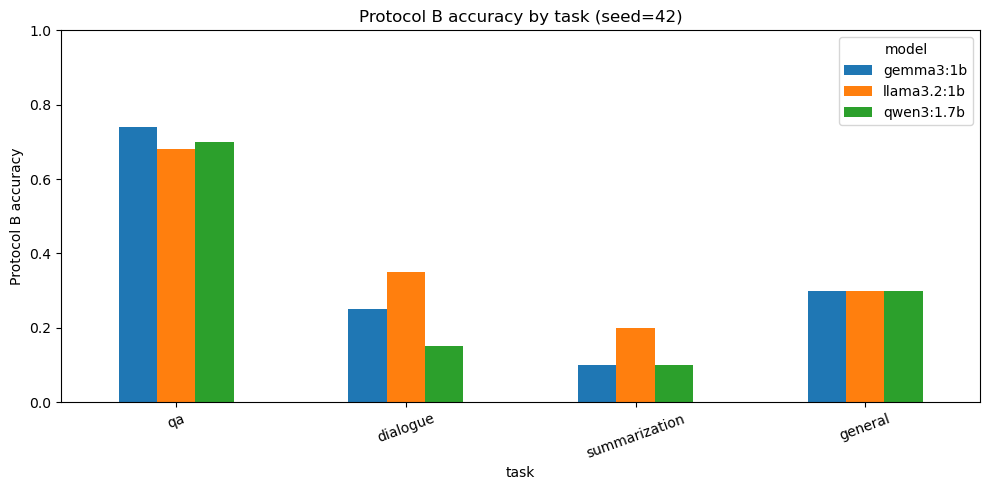

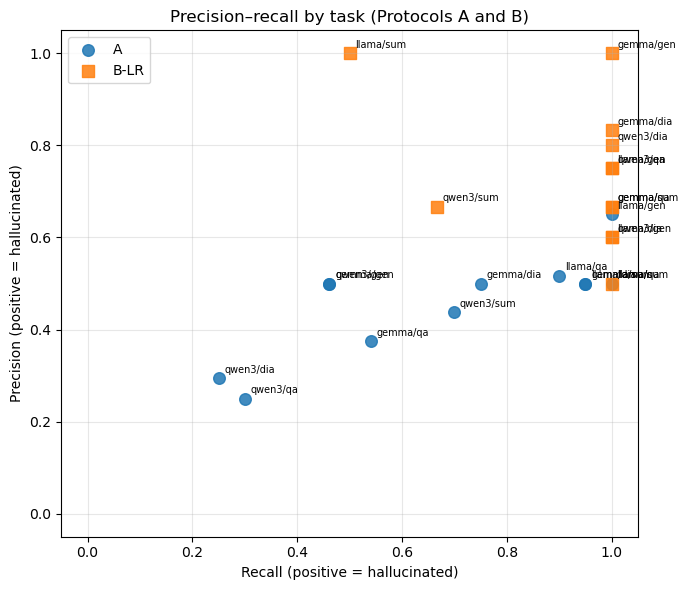

wrote ../results/figure_captions.md

task_comparison.png:
Figure: Protocol B task comparison. Grouped bars show free-generation accuracy (seed=42) for each HaluEval task (x-axis) and each evaluated model. Accuracy is the fraction of items where is_correct is True (QA: ground-truth phrase in the answer; other tasks: word_overlap with truth exceeds overlap with the hallucinated reference). Values: gemma3:1b/qa=0.740; gemma3:1b/dialogue=0.250; gemma3:1b/summarization=0.100; gemma3:1b/general=0.300; llama3.2:1b/qa=0.680; llama3.2:1b/dialogue=0.350; llama3.2:1b/summarization=0.200; llama3.2:1b/general=0.300; qwen3:1.7b/qa=0.700; qwen3:1.7b/dialogue=0.150; qwen3:1.7b/summarization=0.100; qwen3:1.7b/general=0.300.

precision_recall_scatter.png:
Figure: Precision–recall scatter. Each point is one (model, task) under Protocol A (circles: Yes/No discrimination) or Protocol B logistic regression on the held-out test split (squares). Positive class = hallucinated for both. X = recall, Y = precisio

In [21]:
scatter_rows = []
for model in MODELS:
    a_path = protocol_a_metrics_path(model)
    b_path = RESULTS_DIR / f"protocol_b_metrics_{model_slug(model)}.csv"
    if a_path.exists():
        a = pd.read_csv(a_path)
        a = a[a["task"] != "overall"]
        for _, r in a.iterrows():
            scatter_rows.append({"model": model, "task": r["task"], "protocol": "A",
                                 "precision": r["precision"], "recall": r["recall"], "f1": r["f1"]})
    if b_path.exists():
        b = pd.read_csv(b_path)
        b = b[(b["task"] != "overall") & (b["detector"] == "logistic_regression")]
        for _, r in b.iterrows():
            scatter_rows.append({"model": model, "task": r["task"], "protocol": "B-LR",
                                 "precision": r["precision"], "recall": r["recall"], "f1": r["f1"]})

captions = {}
if scored:
    # refresh task_comparison.png from current scored runs
    plot_rows = []
    for model, df in scored.items():
        for task, g in df.groupby("task"):
            plot_rows.append({"model": model, "task": task, "accuracy": g["correct"].mean()})
    plot_df = pd.DataFrame(plot_rows)
    pivot = plot_df.pivot(index="task", columns="model", values="accuracy").reindex(TASKS)
    ax = pivot.plot(kind="bar", figsize=(10, 5))
    ax.set_ylim(0, 1)
    ax.set_ylabel("Protocol B accuracy")
    ax.set_title(f"Protocol B accuracy by task (seed={RANDOM_SEED})")
    ax.legend(title="model")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "task_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    nums = []
    for model in pivot.columns:
        for task in TASKS:
            if task in pivot.index and pd.notna(pivot.loc[task, model]):
                nums.append(f"{model}/{task}={pivot.loc[task, model]:.3f}")
    captions["task_comparison.png"] = (
        "Figure: Protocol B task comparison. Grouped bars show free-generation accuracy "
        f"(seed={RANDOM_SEED}) for each HaluEval task (x-axis) and each evaluated model. "
        "Accuracy is the fraction of items where is_correct is True (QA: ground-truth phrase "
        "in the answer; other tasks: word_overlap with truth exceeds overlap with the "
        f"hallucinated reference). Values: {'; '.join(nums)}."
    )

if scatter_rows:
    sdf = pd.DataFrame(scatter_rows)
    fig, ax = plt.subplots(figsize=(7, 6))
    markers = {"A": "o", "B-LR": "s"}
    for protocol, g in sdf.groupby("protocol"):
        ax.scatter(g["recall"], g["precision"], marker=markers.get(protocol, "x"), s=70, label=protocol, alpha=0.85)
        for _, r in g.iterrows():
            ax.annotate(f"{r['model'].split(':')[0][:5]}/{r['task'][:3]}",
                        (r["recall"], r["precision"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Recall (positive = hallucinated)")
    ax.set_ylabel("Precision (positive = hallucinated)")
    ax.set_title("Precision–recall by task (Protocols A and B)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "precision_recall_scatter.png", dpi=150, bbox_inches="tight")
    plt.show()
    support = "; ".join(
        f"{r.protocol}/{r.model}/{r.task}: P={r.precision:.2f} R={r.recall:.2f} F1={r.f1:.2f}"
        for r in sdf.itertuples()
    )
    captions["precision_recall_scatter.png"] = (
        "Figure: Precision–recall scatter. Each point is one (model, task) under Protocol A "
        "(circles: Yes/No discrimination) or Protocol B logistic regression on the held-out "
        "test split (squares). Positive class = hallucinated for both. X = recall, Y = precision; "
        f"top-right is best. Supporting numbers: {support}."
    )
else:
    print("MISSING precision/recall points — run Protocol A and Step 2 first")

cap_path = RESULTS_DIR / "figure_captions.md"
lines = ["# Figure captions\n"]
for name, text in captions.items():
    lines.append(f"## `{name}`\n\n{text}\n")
cap_path.write_text("\n".join(lines), encoding="utf-8")
print(f"wrote {cap_path}")
for name, text in captions.items():
    print("\n" + name + ":")
    print(text)


## Comparison graph — accuracy by task × model

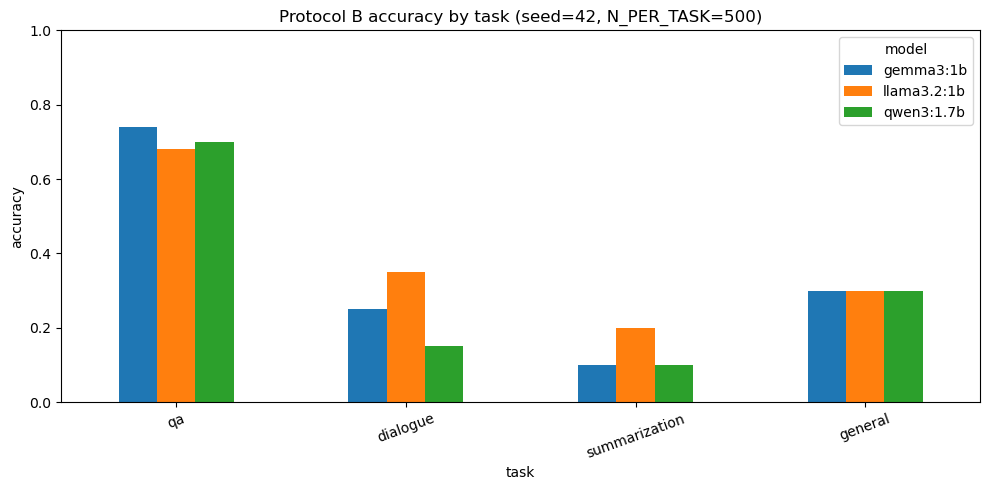

In [22]:
if not scored:
    print("No scored models to plot.")
else:
    plot_rows = []
    for model, df in scored.items():
        for task, g in df.groupby("task"):
            plot_rows.append({"model": model, "task": task, "accuracy": g["correct"].mean()})
    plot_df = pd.DataFrame(plot_rows)
    pivot = plot_df.pivot(index="task", columns="model", values="accuracy").reindex(TASKS)

    ax = pivot.plot(kind="bar", figsize=(10, 5))
    ax.set_ylim(0, 1)
    ax.set_ylabel("accuracy")
    ax.set_title(f"Protocol B accuracy by task (seed={RANDOM_SEED}, N_PER_TASK={N_PER_TASK})")
    ax.legend(title="model")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "task_comparison_all_models.png", dpi=150, bbox_inches="tight")
    plt.show()
    pivot.round(3)